In [1]:
import pandas as pd
import re
import string
import nltk
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ensure NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from spellchecker import SpellChecker
import matplotlib.pyplot as plt
from pywaffle import Waffle

[nltk_data] Downloading package punkt to /home/abdallah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/abdallah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/abdallah/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/abdallah/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv('spooky.csv')
spell = SpellChecker()
stop_words = set(stopwords.words('english'))

In [7]:
df.head()

,id,text,author,clean_text
0,id26305,"This process, however, afforded me no means of...",EAP,process however afforded means ascertaining di...
1,id17569,It never once occurred to me that the fumbling...,HPL,never occurred fumbling might mere mistake
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP,left hand gold snuff box capered hill cutting ...
3,id27763,How lovely is spring As we looked from Windsor...,MWS,lovely spring looked windsor terrace sixteen f...
4,id12958,"Finding nothing else, not even gold, the Super...",HPL,finding nothing else even gold superintendent ...


In [3]:
def clean_text(text):
        text = text.lower()

        homoglyphs = {'$': 's', '@': 'a'}
        for char, repl in homoglyphs.items():
            text = text.replace(char, repl)
        
        #URL/HTML
        text = re.sub(r'http\S+|www\.\S+', '', text)
        text = re.sub(r'<.*?>', '', text)
        # remove emails with the form [Username] @ [Domain] . [Extension]
        text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        1
        # punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        



        tokens = word_tokenize(text)
        
        stop_words = set(stopwords.words('english'))
        clean_tokens = []
        

        #Correction orthographique (pyspellchecker) it removed cause its too slow 
        #corrected = spell.correction(text)
        for w in tokens:
            # les mots-vide + mots < 3 chars
            if w not in stop_words and len(w) >= 3:
                
            
                # The regex r'(.)\1{2,}' finds any char repeated 3+ times.
                if re.search(r'(.)\1{2,}', w):
                    #Correction orthographique (pyspellchecker)
                    corrected = spell.correction(w)
                    if corrected:
                        clean_tokens.append(corrected)
                    else:
                        # Fallback: remove repetitions manually if spell check fails
                        clean_tokens.append(re.sub(r'(.)\1{2,}', r'\1\1', w))
                else:
                    # if no crazy repetition keep the word as is
                    clean_tokens.append(w)
                    
        return ' '.join(clean_tokens)

In [4]:
df['clean_text'] = df['text'].apply(clean_text)

In [5]:
df['clean_text'].head()

0    process however afforded means ascertaining di...
1           never occurred fumbling might mere mistake
2    left hand gold snuff box capered hill cutting ...
3    lovely spring looked windsor terrace sixteen f...
4    finding nothing else even gold superintendent ...
Name: clean_text, dtype: object

In [ ]:

df.to_csv('my_full_dataset.csv', index=False)
df1 = pd.read_csv('my_full_dataset.csv')
df1.head()

,id,text,author,clean_text
0,id26305,"This process, however, afforded me no means of...",EAP,process however afforded means ascertaining di...
1,id17569,It never once occurred to me that the fumbling...,HPL,never occurred fumbling might mere mistake
2,id11008,"In his left hand was a gold snuff box, from wh...",EAP,left hand gold snuff box capered hill cutting ...
3,id27763,How lovely is spring As we looked from Windsor...,MWS,lovely spring looked windsor terrace sixteen f...
4,id12958,"Finding nothing else, not even gold, the Super...",HPL,finding nothing else even gold superintendent ...


In [32]:
# 1. Count "Great" per author (case insensitive)
df['great_count'] = df['text'].str.count(r'(?i)\bgreat\b')
print("--- Occurrences of 'Great' by Author ---")
print(df.groupby('author')['great_count'].sum())

--- Occurrences of 'Great' by Author ---
author
EAP    227
HPL    195
MWS     90
Name: great_count, dtype: int64


In [33]:
# 2. Count "impossible" per author
df['impossible_count'] = df['text'].str.count(r'(?i)\bimpossible\b')
print("\n--- Occurrences of 'impossible' by Author ---")
print(df.groupby('author')['impossible_count'].sum())


--- Occurrences of 'impossible' by Author ---
author
EAP    64
HPL    16
MWS    19
Name: impossible_count, dtype: int64


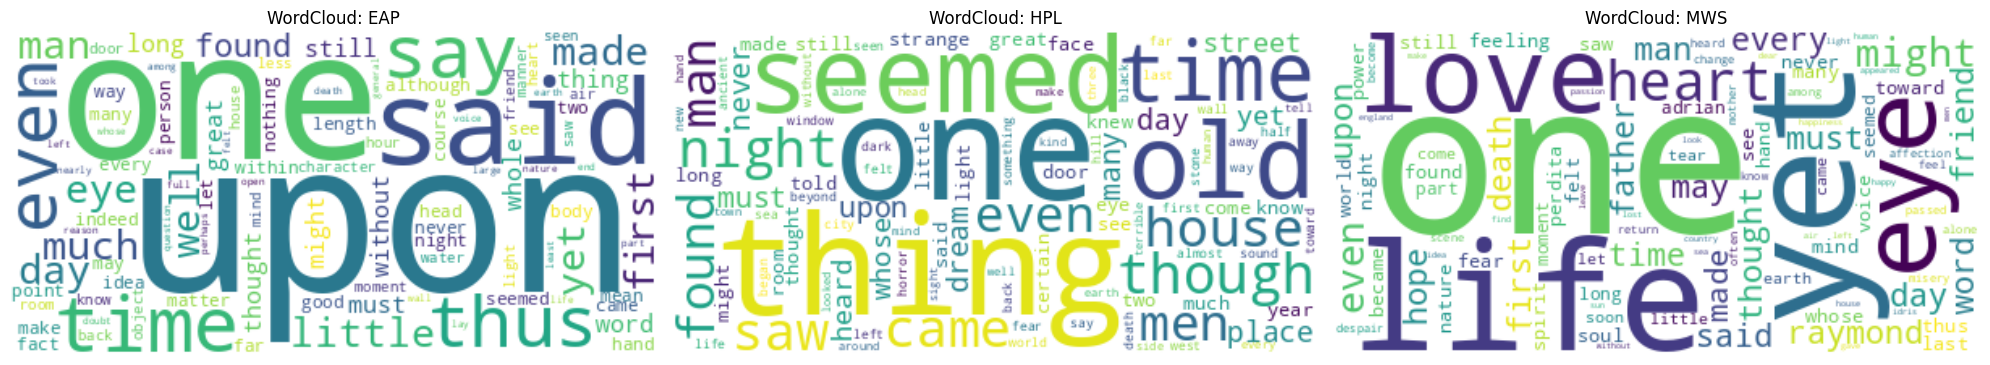

In [9]:
authors = df['author'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, author in enumerate(authors):
    text_subset = " ".join(df[df['author'] == author]['clean_text'])
    wc = WordCloud(background_color='white', max_words=100).generate(text_subset)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"WordCloud: {author}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /home/abdallah/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


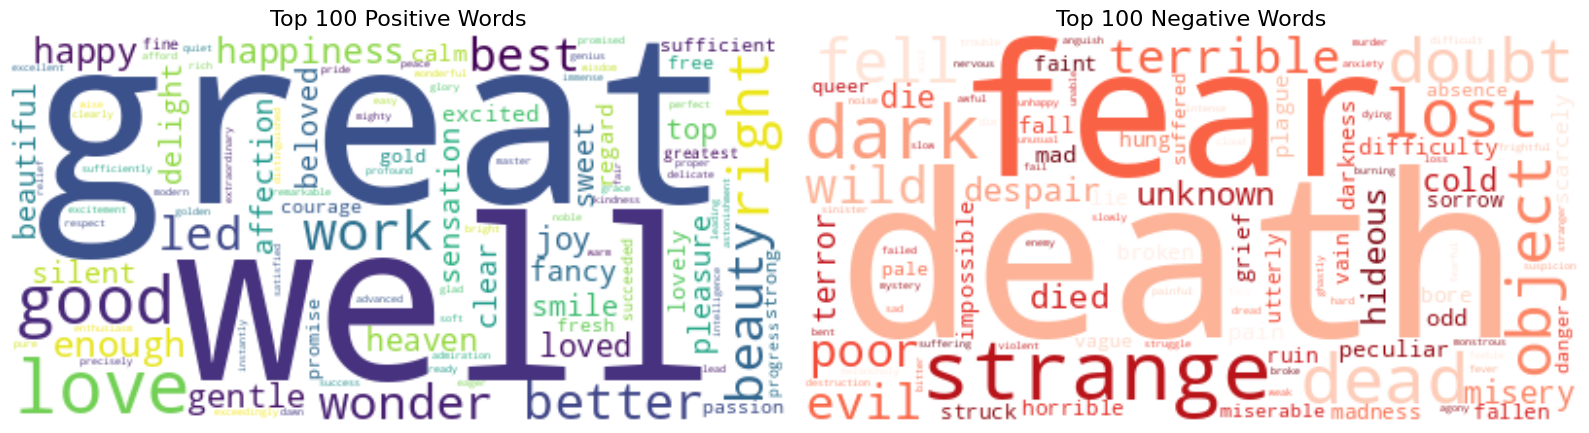

In [ ]:

from nltk.corpus import opinion_lexicon

nltk.download('opinion_lexicon')

# 1. Get the sets of positive and negative words
pos_refs = set(opinion_lexicon.positive())
neg_refs = set(opinion_lexicon.negative())

# 2. Collect all words from your cleaned text
all_text = " ".join(df['clean_text'])
all_words = all_text.split()

# 3. Filter the words
# We only keep words that appear in the positive or negative lists
positive_words_found = [w for w in all_words if w in pos_refs]
negative_words_found = [w for w in all_words if w in neg_refs]

# 4. Generate the WordClouds
# Colormap 'viridis' for positive (green/blueish), 'Reds' for negative
wc_pos = WordCloud(background_color='white', max_words=100, colormap='viridis').generate(" ".join(positive_words_found))
wc_neg = WordCloud(background_color='white', max_words=100, colormap='Reds').generate(" ".join(negative_words_found))

# 5. Display them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Positive Plot
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title("Top 100 Positive Words", fontsize=16)
axes[0].axis('off')

# Negative Plot
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title("Top 100 Negative Words", fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()